In [1]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import NeutrinoGravNetFASER
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import (
    evaluate_gravnet_model,
    evaluate_pointnetpp_model,
)
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

In [56]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nun = NuType(0, "nun", "NC")
nue = NuType(1, "nue", r"CC $\nu_{e}$")
num = NuType(2, "num", r"CC $\nu_{\mu}$")
nut = NuType(3, "nut", r"CC $\nu_{\tau}$")
nus = [nun, nue, num, nut]

# Main

In [5]:
model = "gravnet_faser"
weights_path = (
    get_weights_path()
    / "gravnet_graph_faser_all_events_nut_5mm_0_scint_layerbest_model.pt"
)
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

In [6]:
# Test dataset
# data_path = get_torch_path() / "pointnetpp/test_dataset.pt"
# test_dataset = torch.load(data_path)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

In [11]:
def get_str_from_run(run: int) -> str:
    """Convert run number to string label."""
    if run >= 10000:
        run -= 10000
    if run % 4 == 0:
        return "nue"
    elif run % 4 == 1:
        return "num"
    elif run % 4 == 2:
        return "nut"
    elif run % 4 == 3:
        return "nun"

In [12]:
def load_data(
    run: int, chunks: list[int], data_dir: str, num_events: int | None = None
) -> list[torch.Tensor]:
    torch_path = get_torch_path()
    dataset = []
    truth_dfs = []
    for chunk in chunks:
        run_str = get_str_from_run(run)
        chunk_path = torch_path / f"{run}/{data_dir}"
        chunk_data = torch.load(
            chunk_path / f"{run_str}_{chunk:03d}.pt", weights_only=False
        )
        truth_df = pd.read_parquet(chunk_path / f"{run_str}_{chunk:03d}_truth.parq")
        if num_events is not None:
            chunk_data = chunk_data[:num_events]
            truth_df = truth_df.iloc[:num_events]
        dataset.extend(chunk_data)
        truth_dfs.append(truth_df)
    return dataset, pd.concat(truth_dfs, ignore_index=True)

In [14]:
# We create the datasets only once (but stored them in the pointnetpp directory)
data_model = "gravnet_faser_truth"
torch_path = get_torch_path()
nue_path = torch_path / f"10000/{data_model}"
num_path = torch_path / f"10001/{data_model}"
nut_path = torch_path / f"10002/{data_model}"
nun_path = torch_path / f"10003/{data_model}"

num_events = -1
nue_dataset = torch.load(nue_path / "nue_000.pt", weights_only=False)[:num_events]
nue_truth_df = pd.read_parquet(nue_path / "nue_000_truth.parq")[:num_events]
num_dataset = torch.load(num_path / "num_000.pt", weights_only=False)[:num_events]
num_truth_df = pd.read_parquet(num_path / "num_000_truth.parq")[:num_events]
nun_dataset = torch.load(nun_path / "nun_000.pt", weights_only=False)[:num_events]
nun_truth_df = pd.read_parquet(nun_path / "nun_000_truth.parq")[:num_events]
nut_data, nut_truth = load_data(
    run=10002, chunks=list(range(10)), data_dir=data_model, num_events=None
)
dataset = nue_dataset + num_dataset + nut_data + nun_dataset
truth_df = pd.concat(
    [nue_truth_df, num_truth_df, nut_truth, nun_truth_df], ignore_index=True
)

In [15]:
n_truth = len(truth_df)
n_dataset = len(dataset)
if n_truth != n_dataset:
    raise ValueError(
        f"Length of truth_df ({n_truth}) and dataset ({n_dataset}) do not match!"
    )

In [19]:
from analysis.gravnet.model import NeutrinoGravNetTruth

In [ ]:
weights_path = Path(
    "/Users/tboeckh/Documents/faser/neutrino-detector/data/weights/gravnet_graph_faser_all_events_nut_5mm_0_scint_layer/best_model.pt"
)

In [22]:
device = get_device("cpu")

# model = NeutrinoGravNetFASER(
#     input_dim=dataset[0].x.shape[1],
#     num_graph_classes=len(nus),
#     faser_dim=dataset[0].x_faser.shape[0],
# ).to(device)
# model = model.to(device)

model = NeutrinoGravNetTruth(
    input_dim=4,
    num_graph_classes=4,
    faser_dim=13,
    predict_charm=False,
    dropout=0.2,
    k=12,
).to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [26]:
def evaluate_gravnet_model_truth(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    use_faser: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for data in tqdm(test_loader, desc="Evaluating"):
            data = data.to(device)

            try:
                output = model(data.x, data.pos, data.batch, data.x_event)

                # Check for batch size mismatch
                num_graphs = data.y_graph.size(0)
                if output.size(0) != num_graphs:
                    continue

                probabilities = torch.softmax(output, dim=1)
                predictions = output.argmax(dim=1)

                all_targets.extend(data.y_graph.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

            except RuntimeError as e:
                # Skip batches with errors
                continue

    return np.array(all_targets), np.array(all_predictions), np.array(all_probabilities)

In [38]:
dataset = nue_dataset + num_dataset + nut_data + nun_dataset
truth_df = pd.concat(
    [nue_truth_df, num_truth_df, nut_truth, nun_truth_df], ignore_index=True
)

In [39]:
data_loader = DataLoader(dataset)
y_true, y_pred, y_prob = evaluate_gravnet_model_truth(
    model=model,
    test_loader=data_loader,
    device=device,
    use_faser=True,
    # model=model, test_loader=test_loader, device=device
)

Evaluating:   0%|          | 0/4354 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 4354/4354 [27:37<00:00,  2.63it/s]    


In [40]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[nu.label for nu in nus]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nue: 75.8%
num: 96.6%
nun: 98.8%
nut: 89.6%
average: 90.2%


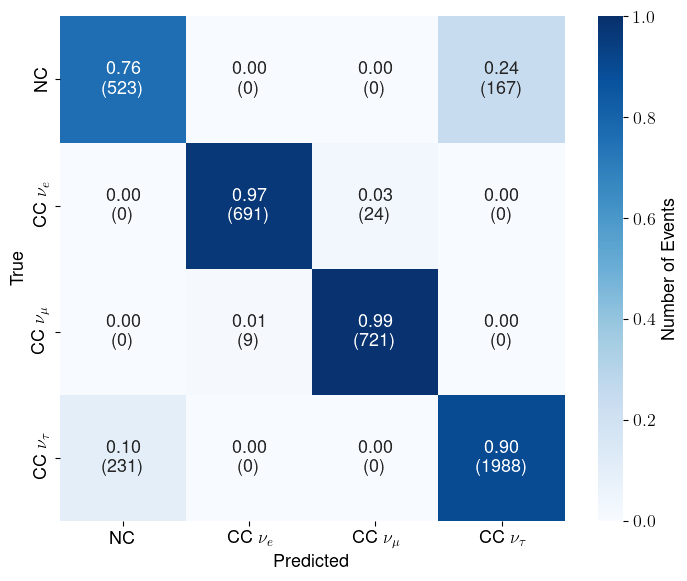

In [58]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[nu.latex_name for nu in nus]
)

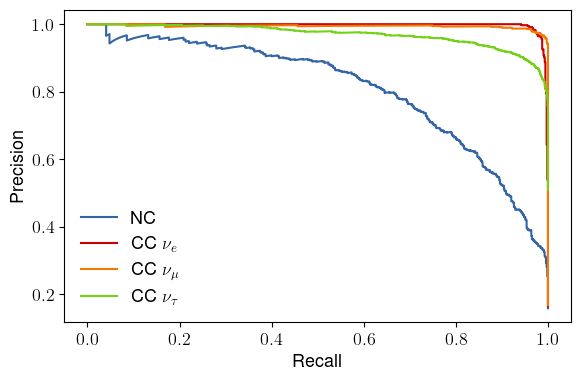

In [59]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

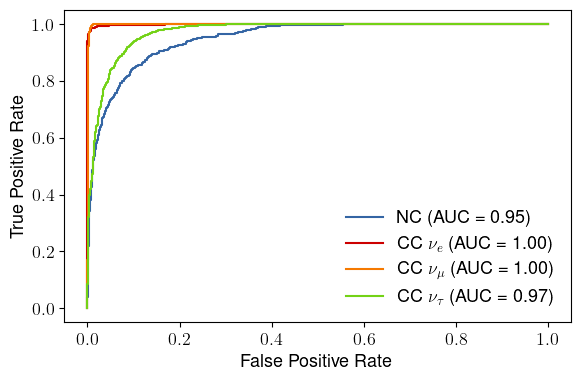

In [60]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

690.0
690.0
690.0
690.0


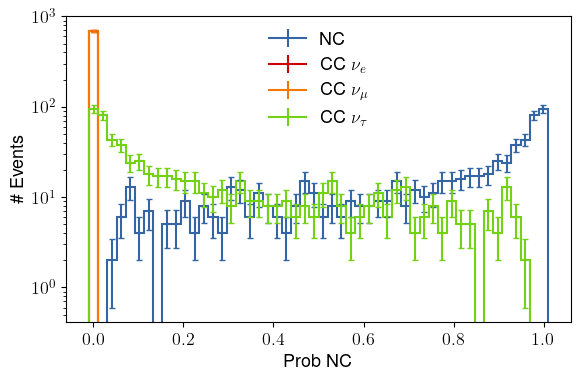

715.0
715.0
715.0
715.0


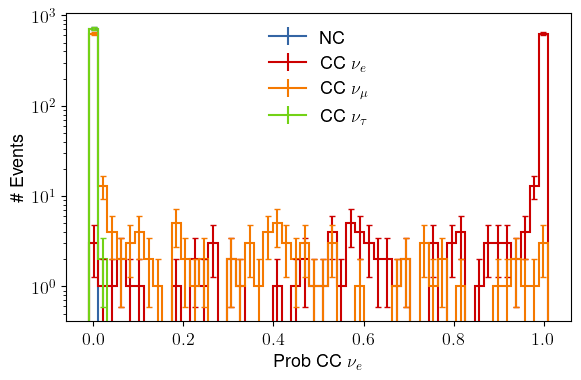

730.0
730.0
730.0
730.0


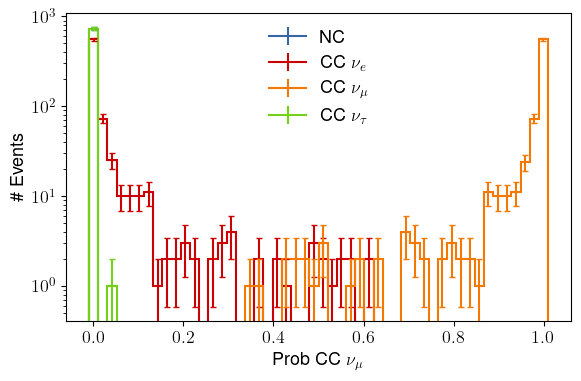

2219.0
2219.0
2219.0
2219.0


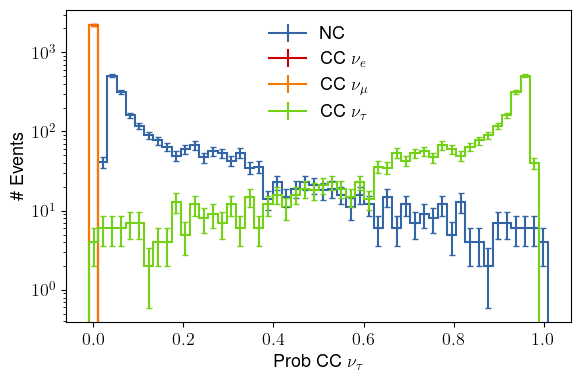

In [61]:
plot_probabilities(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    yscale="log",
)

## Figure-of-merit

In [63]:
from analysis.utils.eval_utils import (
    HitType,
    NuType,
    compute_binned_accuracy,
    evaluate_pointnetpp_model,
    load_data,
    optimize_probability_cut,
    plot_event_counts_vs_energy,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

In [71]:
num_nu_df = pd.read_parquet(get_parquet_path() / "nhits.parq").iloc[0]
num_nus = num_nu_df[["nun", "nue", "num", "nut"]].values
display(num_nu_df)
print(num_nus)

setup              0.000000
W_thickness        5.000000
n_layers         150.000000
n_scint            0.000000
mass             754.598241
nue             3005.264827
num            16568.580150
nut               53.978423
nun             6200.099294
Name: 0, dtype: float64

[ 6200.09929423  3005.26482673 16568.58015034    53.97842295]


In [72]:
nun_idx = 0
nun_threshold, nun_sig, nun_bgr, nun_fom, nun_eff, nun_bgr_rej, nun_results = (
    optimize_probability_cut(
        y_true=y_true,
        y_prob=y_prob,
        signal_class=nun_idx,
        class_counts=num_nus,
    )
)
nun_total = num_nus[nun_idx]

nue_idx = 1
nue_threshold, nue_sig, nue_bgr, nue_fom, nue_eff, nue_bgr_rej, nue_results = (
    optimize_probability_cut(
        y_true=y_true,
        y_prob=y_prob,
        signal_class=nue_idx,
        class_counts=num_nus,
    )
)
nue_total = num_nus[nue_idx]

num_idx = 2
num_threshold, num_sig, num_bgr, num_fom, num_eff, num_bgr_rej, num_results = (
    optimize_probability_cut(
        y_true=y_true,
        y_prob=y_prob,
        signal_class=num_idx,
        class_counts=num_nus,
    )
)
num_total = num_nus[num_idx]

nut_idx = 3
nut_threshold, nut_sig, nut_bgr, nut_fom, nut_eff, nut_bgr_rej, nut_results = (
    optimize_probability_cut(
        y_true=y_true,
        y_prob=y_prob,
        signal_class=nut_idx,
        class_counts=num_nus,
    )
)
nut_total = num_nus[nut_idx]

In [73]:
from analysis.utils.latex_utils import print_latex_df

In [74]:
class_names = [nu.latex_name for nu in nus]

In [76]:
evt_counts = pd.DataFrame(
    {
        "nun": [nun_total, nun_sig, nun_bgr, nun_eff, nun_bgr_rej],
        "nue": [nue_total, nue_sig, nue_bgr, nue_eff, nue_bgr_rej],
        "num": [num_total, num_sig, num_bgr, num_eff, num_bgr_rej],
        "nut": [nut_total, nut_sig, nut_bgr, nut_eff, nut_bgr_rej],
    },
    index=["all", "signal", "bgr", "eff", "pur"],
).T
evt_counts["pur"] *= 100
evt_counts["eff"] *= 100
display(evt_counts)
print_latex_df(
    evt_counts,
    column_names=[
        r"\# Total Events",
        r"\# Signal Events",
        r"\# Bkg. Events",
        r"Efficiency [\%]",
        r"Purity [\%]",
    ],
    index_names=class_names,
)

,all,signal,bgr,eff,pur
nun,6200.099294,3243.820066,251.776119,52.318841,98.717249
nue,3005.264827,2858.153961,12.543368,95.104895,99.945040
num,16568.580150,14798.238710,12.775031,89.315068,99.862031
nut,53.978423,17.319800,48.288420,32.086525,99.812646


\begin{tabular}{lS[table-format=5.1]S[table-format=5.1]S[table-format=3.1]S[table-format=2.1]S[table-format=2.1]}
\toprule
 & {\# Total Events} & {\# Signal Events} & {\# Bkg. Events} & {Efficiency [\%]} & {Purity [\%]} \\
\midrule
NC & 6200.1 & 3243.8 & 251.8 & 52.3 & 98.7 \\
CC $\nu_{e}$ & 3005.3 & 2858.2 & 12.5 & 95.1 & 99.9 \\
CC $\nu_{\mu}$ & 16568.6 & 14798.2 & 12.8 & 89.3 & 99.9 \\
CC $\nu_{\tau}$ & 54.0 & 17.3 & 48.3 & 32.1 & 99.8 \\
\bottomrule
\end{tabular}



## Plot bad events